In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [54]:
sample = pd.read_csv("open/sample_submission.csv")
train = pd.read_csv("open/train.csv")
test = pd.read_csv("open/test.csv")

### Data 시각화

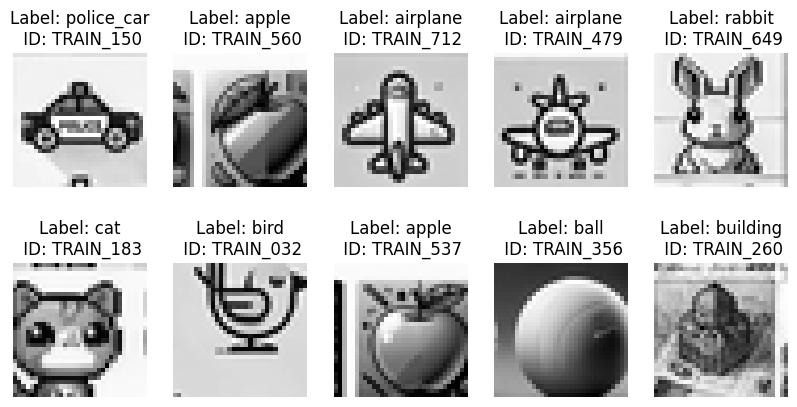

In [45]:
random_indices = np.random.choice(len(df), 10, replace=False)
samples = df.iloc[random_indices]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, (idx, sample) in enumerate(samples.iterrows()):
    image = sample.iloc[2:].values.astype(np.uint8).reshape(32,32)

    row, col = divmod(i, 5)
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f"Label: {sample['label']}\n ID: {sample['ID']}")
    axes[row, col].axis("off")

### Dataset 구성

In [108]:
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import ViTForImageClassification, ViTFeatureExtractor, Trainer, TrainingArguments

In [55]:
label_encoder = LabelEncoder()
train["label"] = label_encoder.fit_transform(train["label"])  # 문자열 라벨을 숫자로 변환

In [67]:
train_idx, val_idx = train_test_split(df.index, test_size=0.2, stratify=df["label"], random_state=42)

In [95]:
class CustomDataset(Dataset):
    def __init__(self, df, transform=None, test = False):
        self.df = df
        self.transform = transform
        self.test = test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = row.iloc[2:].values.astype(np.uint8).reshape(32, 32) 
        label = row["label"]  # class label

        if self.transform:
            image = self.transform(image)
             
        if self.test: # test일 때
            return image
        return image, label

In [96]:
transform = transforms.Compose([
    transforms.ToPILImage(),  # NumPy 배열을 PIL 이미지로 변환
    transforms.Resize((224, 224)),  # ViT 입력 크기로 조정
    transforms.ToTensor(),  # PyTorch Tensor 변환
    transforms.Normalize(mean=[0.5], std=[0.5])  # 정규화
])

train_dataset = CustomDataset(df = train.iloc[train_idx, :], transform=transform)
val_dataset = CustomDataset(df = train.iloc[val_idx, :], transform=transform)
test_dataset = CustomDataset(df = test.iloc[:, 1:], transform=transform, test = True)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Batch Image Shape: torch.Size([16, 1, 224, 224])
Batch Labels Shape: torch.Size([16])


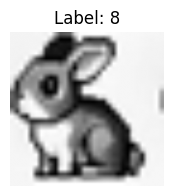

In [113]:
# DataLoader 검증
train_batch = next(iter(train_loader))  
images, labels = train_batch
print(f"Batch Image Shape: {images.shape}")  
print(f"Batch Labels Shape: {labels.shape}")  

plt.figure(figsize=(3,2))
plt.imshow(images[0].permute(1, 2, 0), cmap="gray",)
plt.title(f"Label: {labels[0].item()}")  
plt.axis("off")
plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 10
learning_rate = 5e-5
batch_size = 16


feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=len(label_encoder.classes_),  # 클래스 개수
    ignore_mismatched_sizes=True
)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    train_loss = 0.0
    for images, labels in tqdm(loader, desc="Training", leave=False)::
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0) # 마지막 배치 크기가 작아도 정확하게 반영됨.
        
    one_epoch_loss = train_loss / len(loader.dataset)
    return ope_epoch_loss

@torch.no_grad()
def val_one_epoch(model, loader, criterion, device):
    model.eval()
    val_loss, correct, total = 0, 0, 0
    
    for images, labels in tqdm(loader, desc="Validation", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(pixel_values=images).logits
        loss = criterion(outputs, labels)

        val_loss += loss.item() * images.size(0)
        
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
            
    one_epoch_loss = val_loss / len(loader.dataset)
    acc = correct / total
    return one_epoch_loss, acc

In [ ]:
# train loop
best_loss = 1e9
best_model = None

for epoch in range(num_epochs):
    start_time = time.time()
    # train
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

    val_loss, val_acc = val_one_epoch(model, train_loader, criterion, device)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc*100:.2f}%")

    # Check for best model
    if val_loss < best_loss:
        torch.save(model.state_dict(), "vit-baseline-01.pth")
        best_loss = val_loss
        best_model = model

    scheduler.step()